Threshold-based  →  strip 1: 200→305   strip 2: 347→428
Valley-snapped   →  left: 140   right: 488
Final boundaries →  140 → 538  (width 399 px)


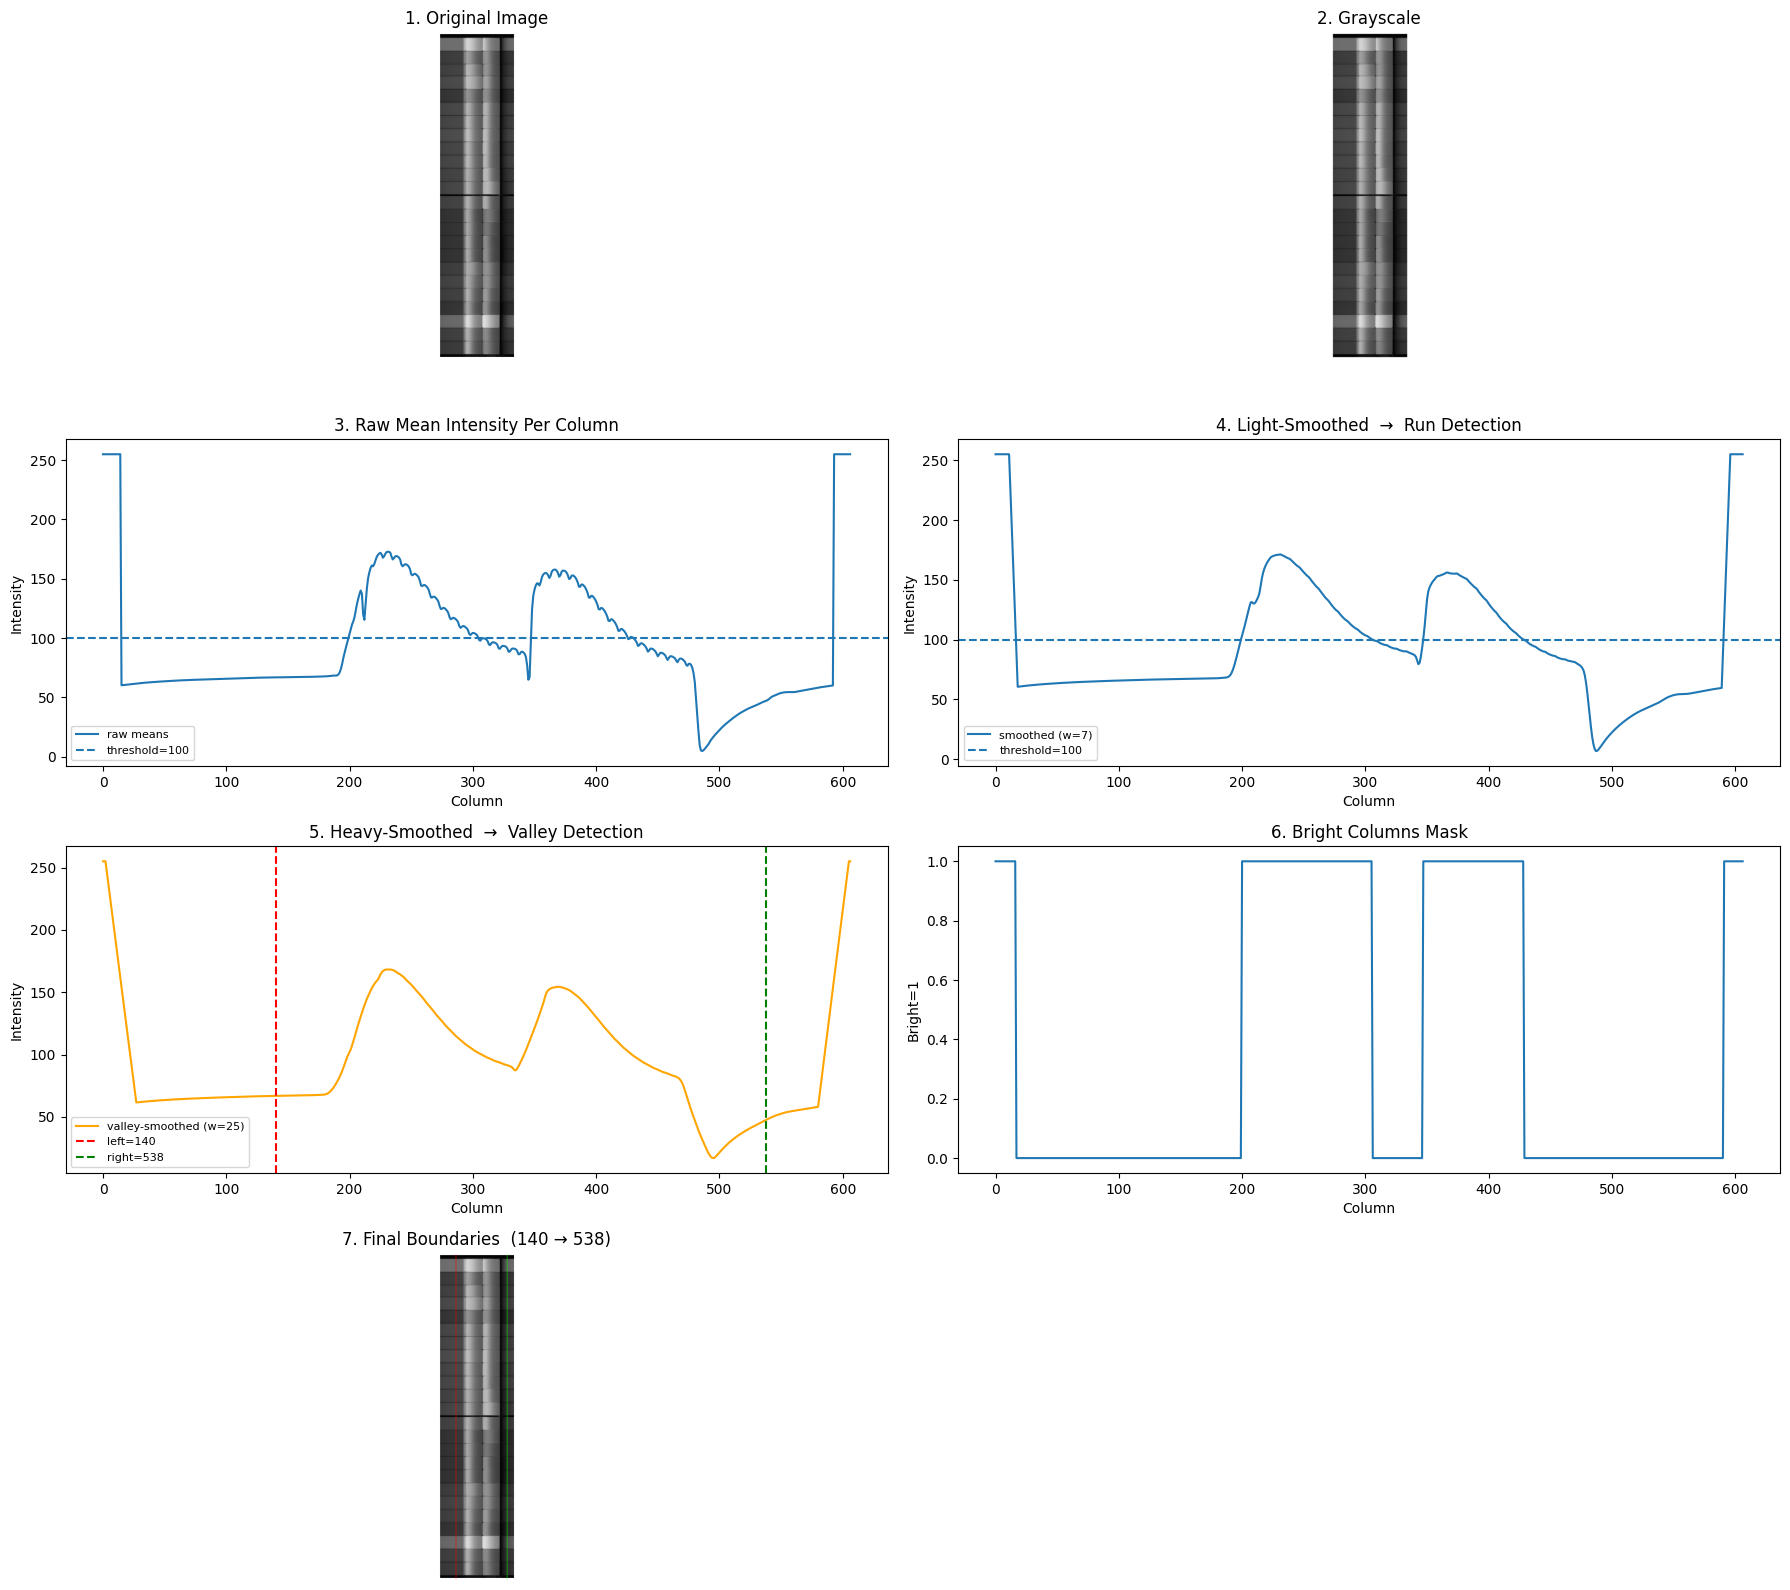

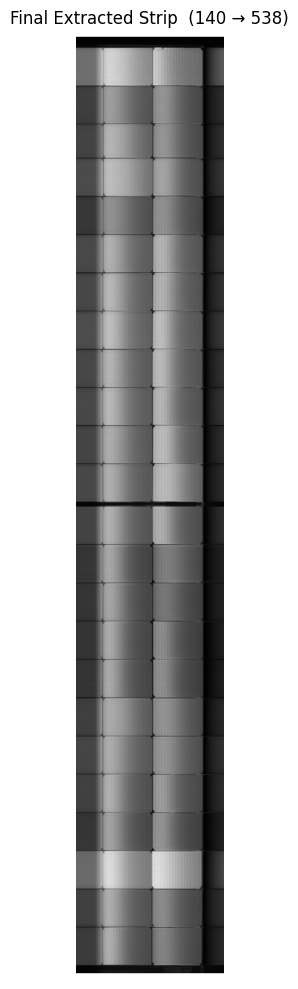

True

In [4]:
import numpy as np
from PIL import Image
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

# ── CONFIG ──────────────────────────────────────────────
INPUT_IMAGE          = "topcon/Images/SEG_3.png"
BRIGHT_THRESH        = 100
SMOOTH_WINDOW        = 7    # smoothing for threshold / run detection
VALLEY_SMOOTH_WINDOW = 25   # heavier smoothing used only for valley detection
VALLEY_SEARCH        = 60   # max px to walk outward looking for nearest valley
EXPAND_LEFT          = 0    # +ve → expand left outward  | -ve → trim left inward
EXPAND_RIGHT         = 50   # +ve → expand right outward | -ve → trim right inward
# ───────────────────────────────────────────────────────


def find_bright_runs(col_means, smooth_window, threshold):
    """Detect the two widest bright column runs on lightly-smoothed signal."""
    smoothed = uniform_filter1d(col_means, size=smooth_window)
    bright   = smoothed > threshold

    runs  = []
    start = None
    for i, v in enumerate(bright):
        if v and start is None:
            start = i
        elif not v and start is not None:
            runs.append((start, i - 1))
            start = None
    if start is not None:
        runs.append((start, len(bright) - 1))

    if not runs:
        raise ValueError(
            f"No bright strip found (threshold={threshold}). "
            "Try lowering BRIGHT_THRESH."
        )

    top2 = sorted(runs, key=lambda r: r[1] - r[0], reverse=True)[:2]
    top2.sort()  # left-to-right order

    (x0, x1)     = top2[0]
    (x0_2, x1_2) = top2[1] if len(top2) > 1 else top2[0]

    return x0, x1, x0_2, x1_2, smoothed, bright


def find_nearest_valley(valley_smoothed, anchor, direction, window):
    """
    Walk outward from anchor on the VALLEY-smoothed signal and return the
    index of the first local minimum (nearest valley bottom).
    """
    n = len(valley_smoothed)
    if direction == "left":
        lo   = max(0, anchor - window)
        prev = valley_smoothed[anchor]
        for i in range(anchor - 1, lo - 1, -1):
            curr = valley_smoothed[i]
            if curr > prev:        # rising leftward → valley was at i+1
                return i + 1
            prev = curr
        return lo                  # fallback: search limit reached
    else:
        hi   = min(n - 1, anchor + window)
        prev = valley_smoothed[anchor]
        for i in range(anchor + 1, hi + 1):
            curr = valley_smoothed[i]
            if curr > prev:        # rising rightward → valley was at i-1
                return i - 1
            prev = curr
        return hi


# ── LOAD IMAGE ──────────────────────────────────────────
img  = Image.open(INPUT_IMAGE)
gray = np.array(img.convert("L"))
rgb  = np.array(img)

# ── STEP 1 : raw column means ─────────────────────────
col_means = gray.mean(axis=0).astype(float)

# ── STEP 2 : light smoothing → run / threshold detection
x0, x1, x0_2, x1_2, smoothed, bright = find_bright_runs(
    col_means, SMOOTH_WINDOW, BRIGHT_THRESH
)
print(f"Threshold-based  →  strip 1: {x0}→{x1}   strip 2: {x0_2}→{x1_2}")

# ── STEP 3 : heavy smoothing → valley detection ────────
valley_smoothed = uniform_filter1d(col_means, size=VALLEY_SMOOTH_WINDOW)

left_edge  = find_nearest_valley(valley_smoothed, x0,   direction="left",  window=VALLEY_SEARCH)
right_edge = find_nearest_valley(valley_smoothed, x1_2, direction="right", window=VALLEY_SEARCH)
print(f"Valley-snapped   →  left: {left_edge}   right: {right_edge}")

# ── STEP 4 : apply manual expansion / trim ─────────────
left_edge  = int(np.clip(left_edge  - EXPAND_LEFT,  0, rgb.shape[1] - 1))
right_edge = int(np.clip(right_edge + EXPAND_RIGHT, 0, rgb.shape[1] - 1))
print(f"Final boundaries →  {left_edge} → {right_edge}  (width {right_edge - left_edge + 1} px)")

# ── EXTRACT SINGLE COMBINED STRIP ─────────────────────
strip = rgb[:, left_edge:right_edge + 1]

# ── ANNOTATE BOUNDARIES ON A COPY ─────────────────────
detected = rgb.copy()
color_l = [255, 0, 0, 255] if detected.shape[2] == 4 else [255, 0, 0]
color_r = [0, 255, 0, 255] if detected.shape[2] == 4 else [0, 255, 0]
detected[:, max(0, left_edge  - 2):left_edge  + 2] = color_l
detected[:, max(0, right_edge - 2):right_edge + 2] = color_r

# ── VISUALIZE ALL STEPS ────────────────────────────────
fig = plt.figure(figsize=(18, 16))

plt.subplot(4, 2, 1)
plt.imshow(rgb)
plt.title("1. Original Image")
plt.axis("off")

plt.subplot(4, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("2. Grayscale")
plt.axis("off")

plt.subplot(4, 2, 3)
plt.plot(col_means, label="raw means")
plt.axhline(BRIGHT_THRESH, linestyle="--", label=f"threshold={BRIGHT_THRESH}")
plt.title("3. Raw Mean Intensity Per Column")
plt.xlabel("Column")
plt.ylabel("Intensity")
plt.legend(fontsize=8)

plt.subplot(4, 2, 4)
plt.plot(smoothed, label=f"smoothed (w={SMOOTH_WINDOW})")
plt.axhline(BRIGHT_THRESH, linestyle="--", label=f"threshold={BRIGHT_THRESH}")
plt.title("4. Light-Smoothed  →  Run Detection")
plt.xlabel("Column")
plt.ylabel("Intensity")
plt.legend(fontsize=8)

plt.subplot(4, 2, 5)
plt.plot(valley_smoothed, color="orange", label=f"valley-smoothed (w={VALLEY_SMOOTH_WINDOW})")
plt.axvline(left_edge,  color="red",   linestyle="--", label=f"left={left_edge}")
plt.axvline(right_edge, color="green", linestyle="--", label=f"right={right_edge}")
plt.title("5. Heavy-Smoothed  →  Valley Detection")
plt.xlabel("Column")
plt.ylabel("Intensity")
plt.legend(fontsize=8)

plt.subplot(4, 2, 6)
plt.plot(bright.astype(int))
plt.title("6. Bright Columns Mask")
plt.xlabel("Column")
plt.ylabel("Bright=1")

plt.subplot(4, 2, 7)
plt.imshow(detected)
plt.title(f"7. Final Boundaries  ({left_edge} → {right_edge})")
plt.axis("off")

plt.tight_layout()
plt.show()

# ── SHOW FINAL EXTRACTED STRIP ─────────────────────────
plt.figure(figsize=(6, 10))
plt.imshow(strip)
plt.title(f"Final Extracted Strip  ({left_edge} → {right_edge})")
plt.axis("off")
plt.tight_layout()
plt.show()

cv2.imwrite("extracted_strip.png", cv2.cvtColor(strip, cv2.COLOR_RGB2BGR))

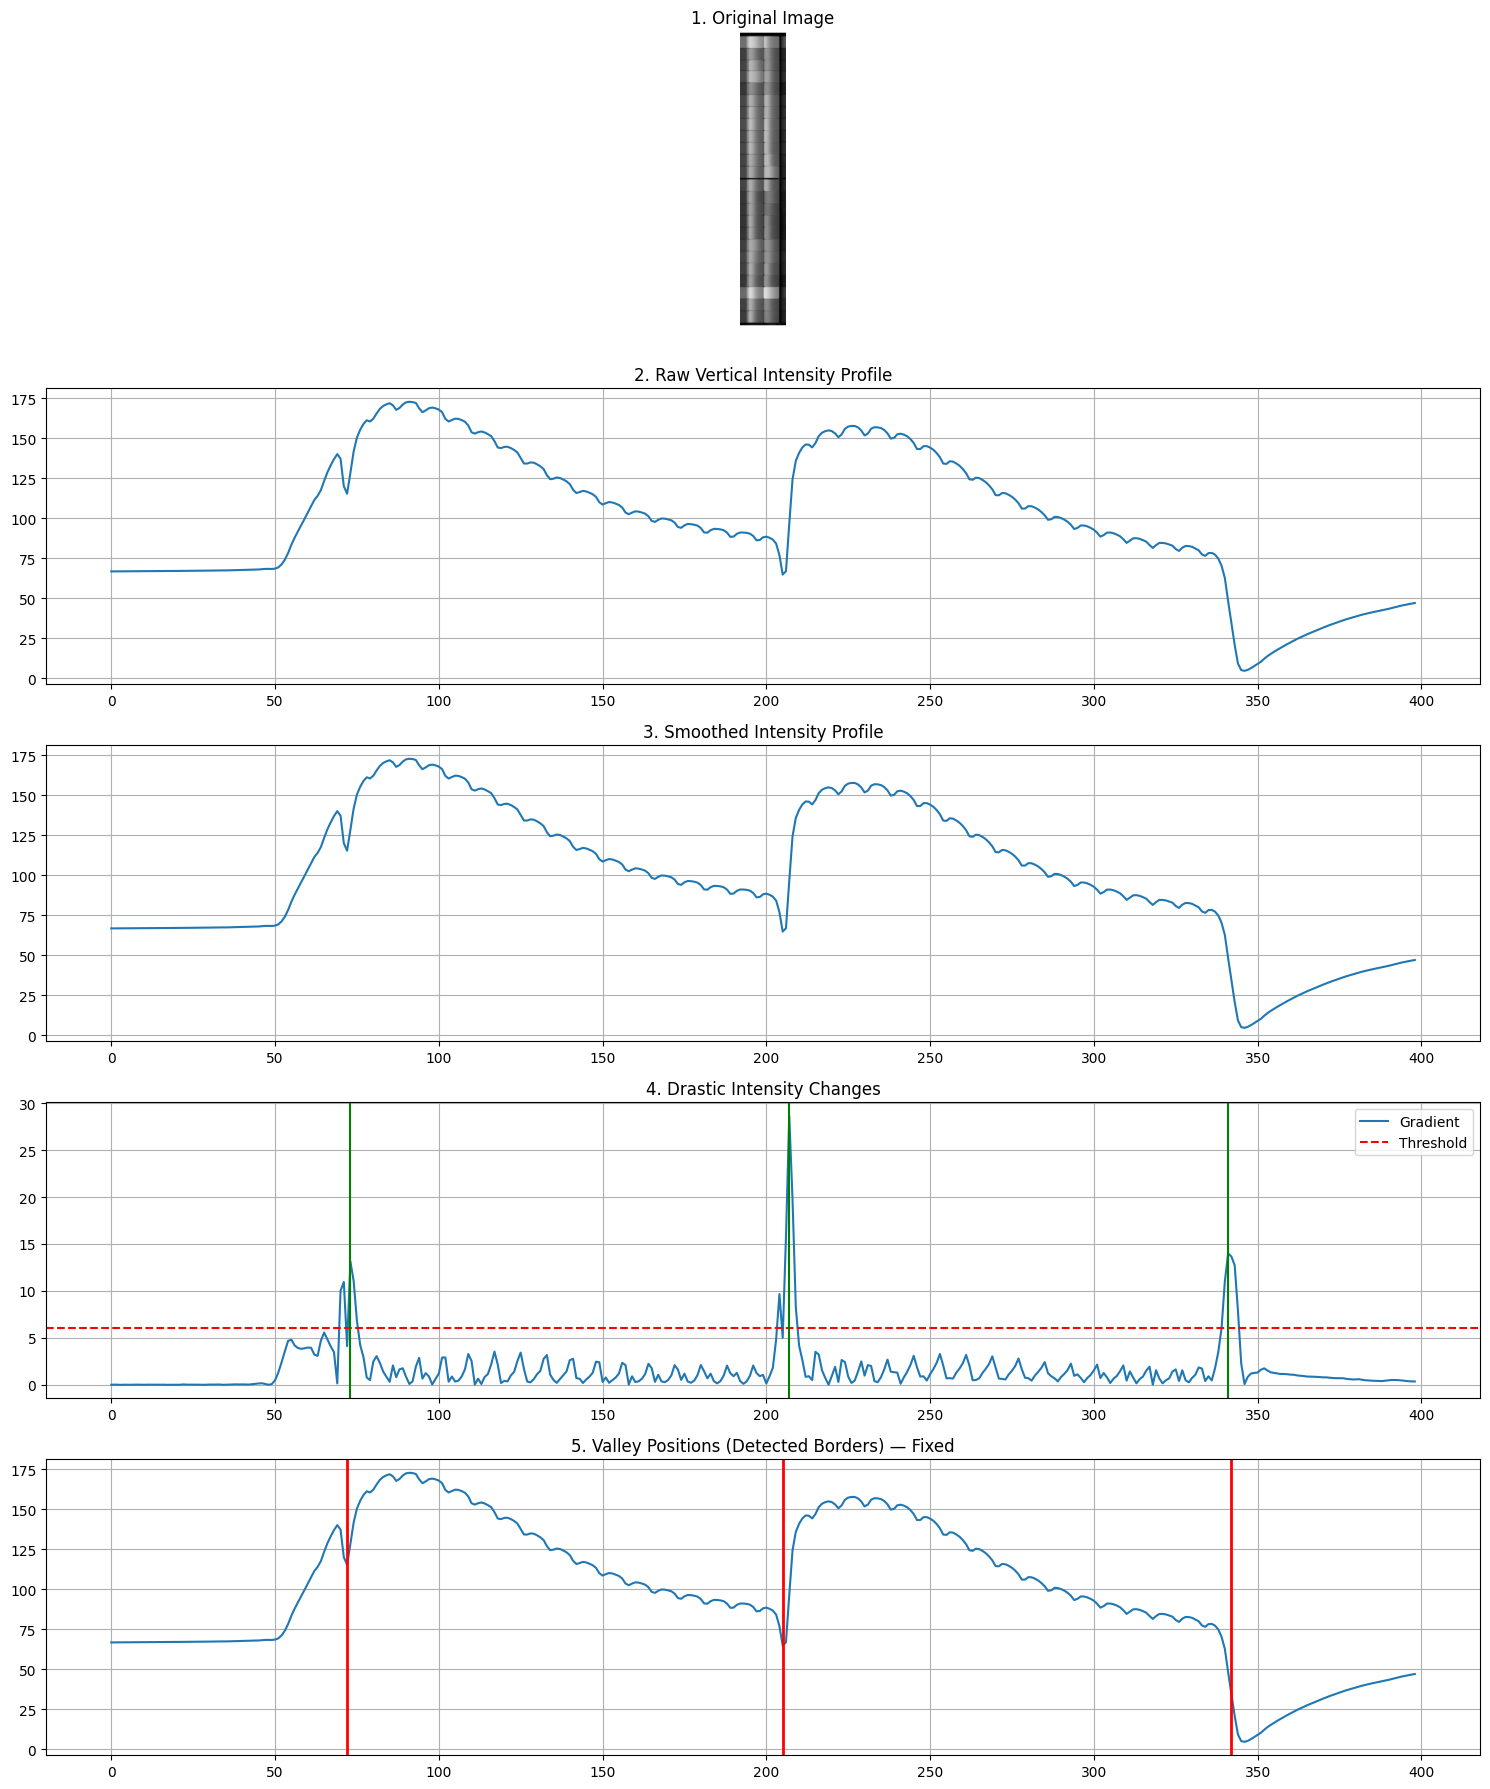

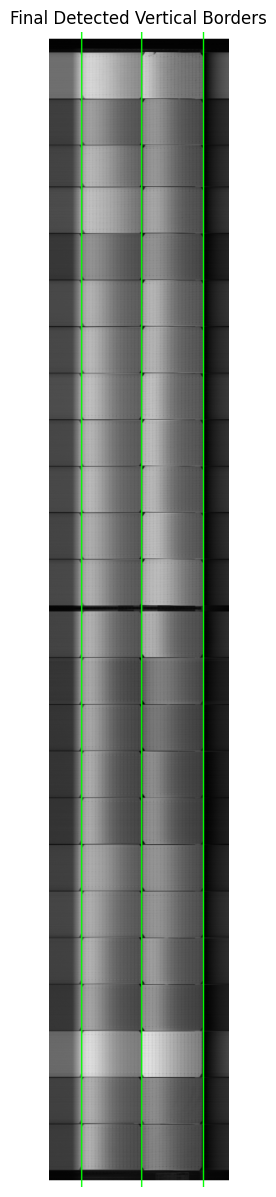

Detected border positions:
[ 72 205 342]


In [5]:

# ============================================================
# DETECT VERTICAL COLUMN BORDERS USING INTENSITY VALLEYS
# ============================================================
# Idea:
# 1. Convert image to grayscale
# 2. Compute vertical intensity profile (mean of each column)
# 3. Smooth profile
# 4. Compute intensity change (gradient)
# 5. Find drastic changes
# 6. Around each drastic change find the lowest valley (narrow window)
# 7. Consider valley positions as column borders
# 8. Display every step
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------
img = cv2.imread("extracted_strip.png", cv2.IMREAD_GRAYSCALE)

# ------------------------------------------------------------
# Step 1 : Vertical intensity profile
# ------------------------------------------------------------
profile = img.mean(axis=0)

# ------------------------------------------------------------
# Step 2 : Smooth profile
# ------------------------------------------------------------
profile_smooth = cv2.GaussianBlur(
    profile.reshape(1, -1),
    (1, 31),
    0
).flatten()

# ------------------------------------------------------------
# Step 3 : Gradient (intensity change)
# ------------------------------------------------------------
gradient = np.abs(np.gradient(profile_smooth))

# ------------------------------------------------------------
# Step 4 : Detect strong change locations
# ------------------------------------------------------------
threshold = gradient.mean() + 2 * gradient.std() -1

change_points, _ = find_peaks(
    gradient,
    height=threshold,
    distance=20
)

# ------------------------------------------------------------
# Step 5 : Find valleys in a narrow window AROUND each change point
#           (fixes false picks at image edges x=0 and x=end)
# ------------------------------------------------------------
WINDOW = 2   # px to search either side of each change point
valleys = []

for peak in change_points:
    left  = max(0, peak - WINDOW)
    right = min(len(profile_smooth), peak + WINDOW)
    valley = left + np.argmin(profile_smooth[left:right])
    valleys.append(valley)

valleys = np.array(valleys)

# ------------------------------------------------------------
# Step 6 : Overlay detected borders
# ------------------------------------------------------------
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

for x in valleys:
    cv2.line(
        overlay,
        (x, 0),
        (x, img.shape[0]),
        (0, 255, 0),
        2
    )

# ------------------------------------------------------------
# DISPLAY ALL SUBSTEPS
# ------------------------------------------------------------
fig, ax = plt.subplots(5, 1, figsize=(15, 18))

# 1. Original image
ax[0].imshow(img, cmap='gray')
ax[0].set_title("1. Original Image")
ax[0].axis("off")

# 2. Raw intensity profile
ax[1].plot(profile)
ax[1].set_title("2. Raw Vertical Intensity Profile")
ax[1].grid(True)

# 3. Smoothed profile
ax[2].plot(profile_smooth)
ax[2].set_title("3. Smoothed Intensity Profile")
ax[2].grid(True)

# 4. Gradient + drastic change locations
ax[3].plot(gradient, label="Gradient")
ax[3].axhline(threshold, color='r', linestyle='--', label='Threshold')
for x in change_points:
    ax[3].axvline(x, color='g')
ax[3].set_title("4. Drastic Intensity Changes")
ax[3].legend()
ax[3].grid(True)

# 5. Valley positions (corrected borders)
ax[4].plot(profile_smooth)
for x in valleys:
    ax[4].axvline(x, color='red', linewidth=2)
ax[4].set_title("5. Valley Positions (Detected Borders) — Fixed")
ax[4].grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final Result
# ------------------------------------------------------------
plt.figure(figsize=(6, 15))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Final Detected Vertical Borders")
plt.axis("off")
plt.show()

print("Detected border positions:")
print(valleys)

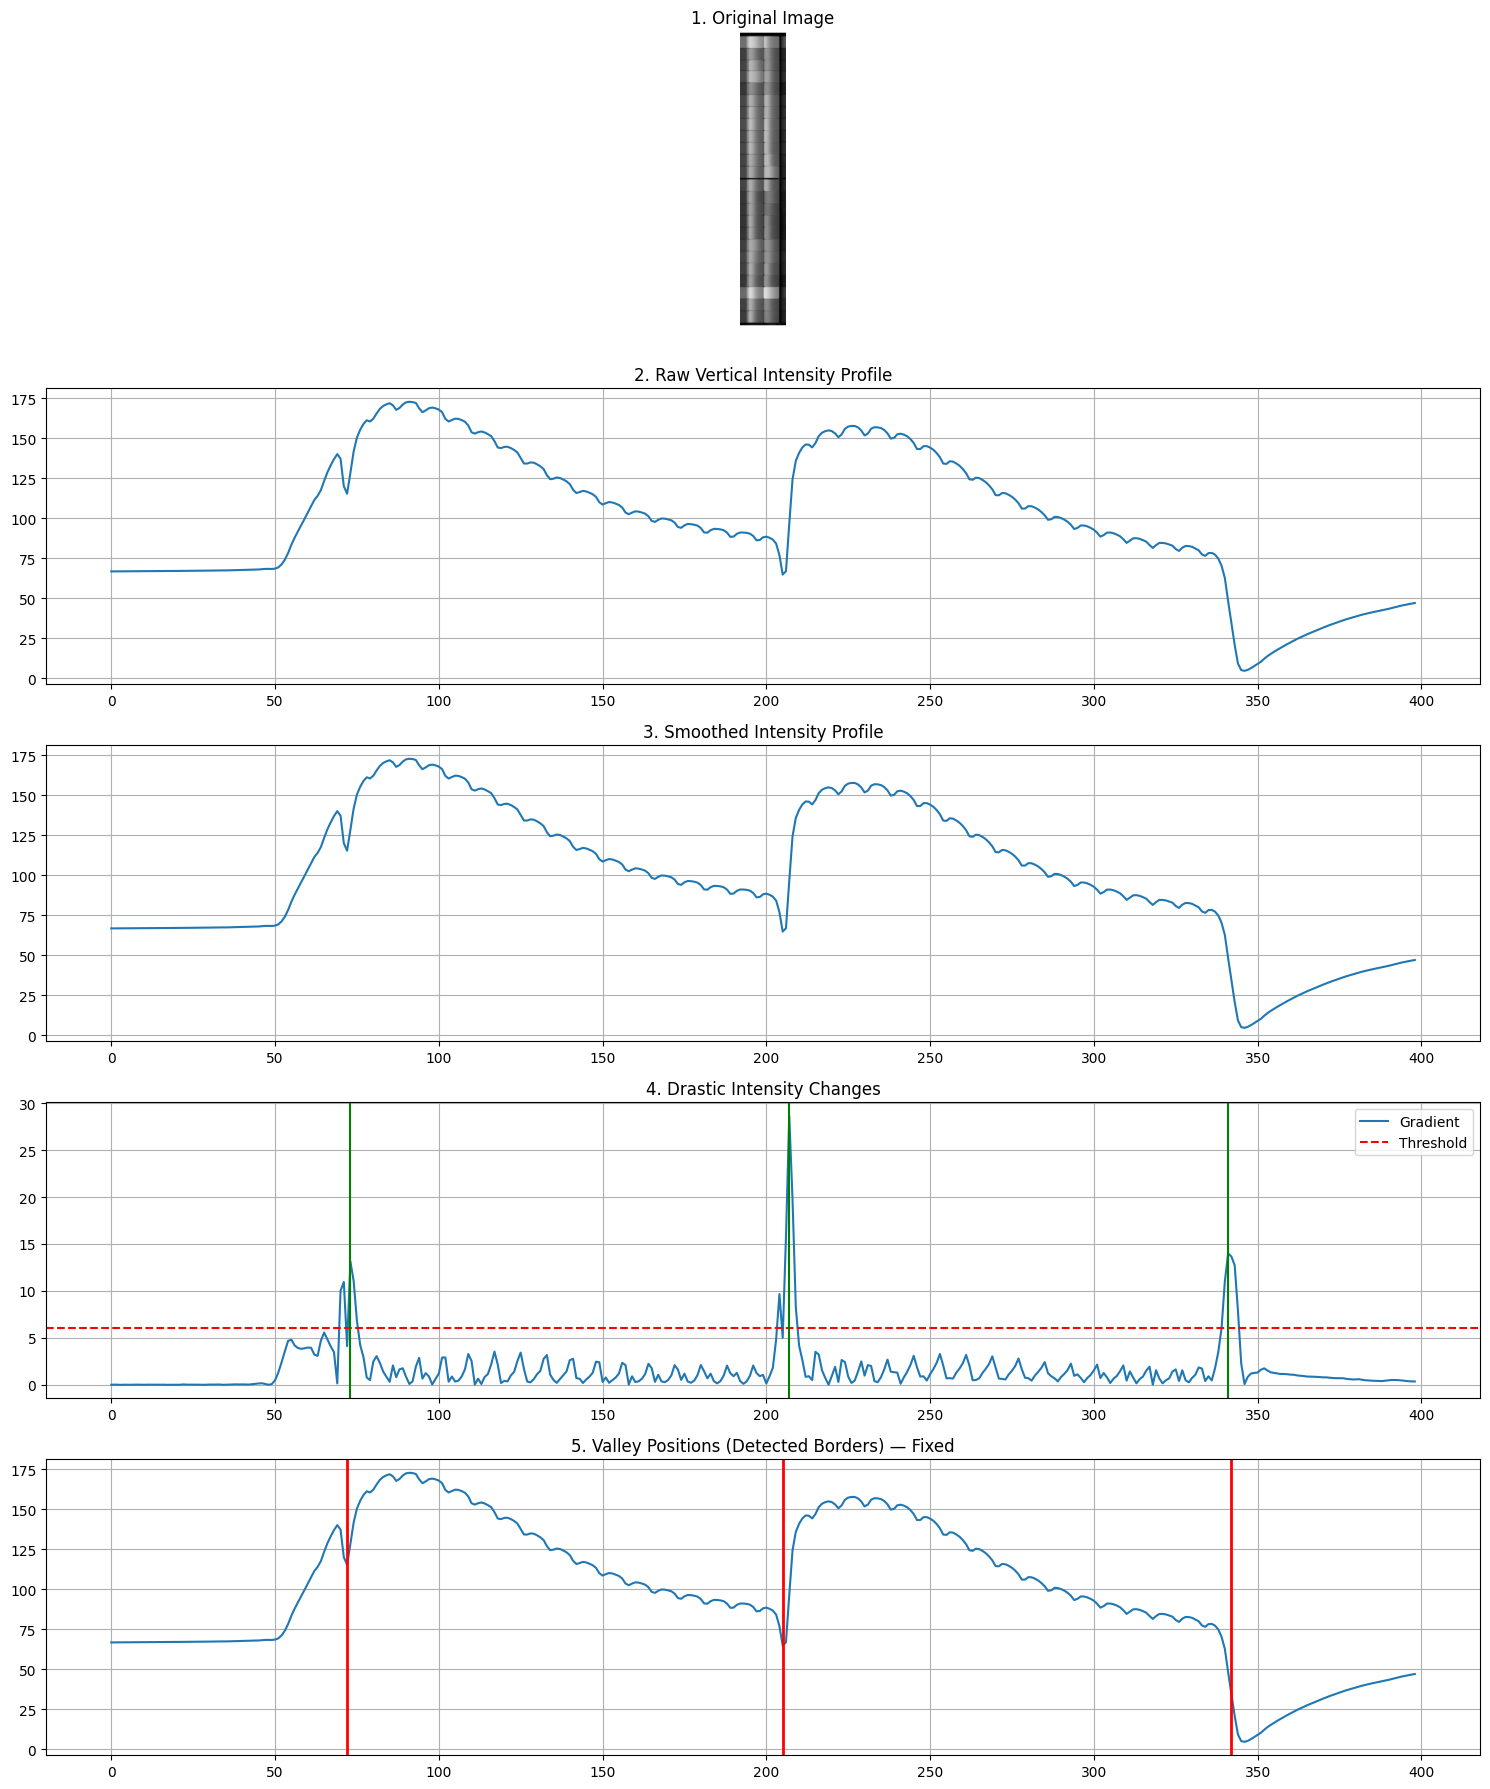

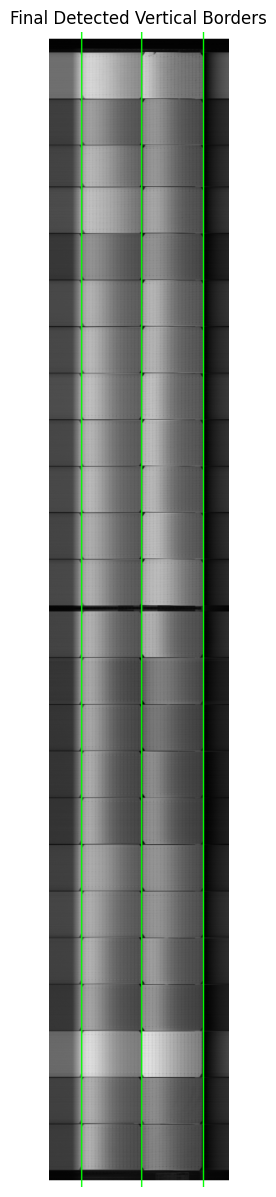

Detected border positions:
[ 72 205 342]


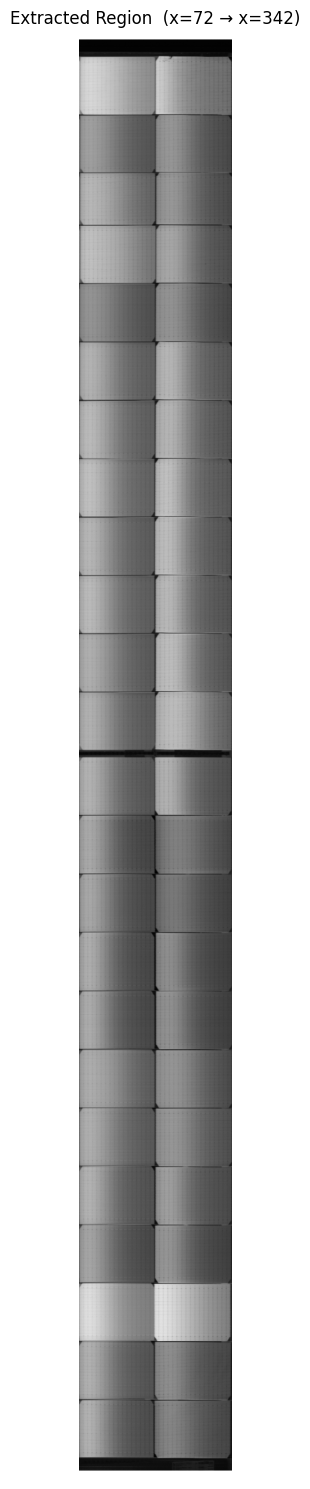


Extracted region saved to 'extracted_content.png'
  Left border  : x = 72
  Right border : x = 342
  Crop width   : 270 px


True

In [6]:
# ============================================================
# DETECT VERTICAL COLUMN BORDERS USING INTENSITY VALLEYS
# ============================================================
# Idea:
# 1. Convert image to grayscale
# 2. Compute vertical intensity profile (mean of each column)
# 3. Smooth profile
# 4. Compute intensity change (gradient)
# 5. Find drastic changes
# 6. Around each drastic change find the lowest valley (narrow window)
# 7. Consider valley positions as column borders
# 8. Display every step
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------
img = cv2.imread("extracted_strip.png", cv2.IMREAD_GRAYSCALE)

# ------------------------------------------------------------
# Step 1 : Vertical intensity profile
# ------------------------------------------------------------
profile = img.mean(axis=0)

# ------------------------------------------------------------
# Step 2 : Smooth profile
# ------------------------------------------------------------
profile_smooth = cv2.GaussianBlur(
    profile.reshape(1, -1),
    (1, 31),
    0
).flatten()

# ------------------------------------------------------------
# Step 3 : Gradient (intensity change)
# ------------------------------------------------------------
gradient = np.abs(np.gradient(profile_smooth))

# ------------------------------------------------------------
# Step 4 : Detect strong change locations
# ------------------------------------------------------------
threshold = gradient.mean() + 2 * gradient.std() -1

change_points, _ = find_peaks(
    gradient,
    height=threshold,
    distance=20
)

# ------------------------------------------------------------
# Step 5 : Find valleys in a narrow window AROUND each change point
#           (fixes false picks at image edges x=0 and x=end)
# ------------------------------------------------------------
WINDOW = 2   # px to search either side of each change point
valleys = []

for peak in change_points:
    left  = max(0, peak - WINDOW)
    right = min(len(profile_smooth), peak + WINDOW)
    valley = left + np.argmin(profile_smooth[left:right])
    valleys.append(valley)

valleys = np.array(valleys)

# ------------------------------------------------------------
# Step 6 : Overlay detected borders
# ------------------------------------------------------------
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

for x in valleys:
    cv2.line(
        overlay,
        (x, 0),
        (x, img.shape[0]),
        (0, 255, 0),
        2
    )

# ------------------------------------------------------------
# DISPLAY ALL SUBSTEPS
# ------------------------------------------------------------
fig, ax = plt.subplots(5, 1, figsize=(15, 18))

# 1. Original image
ax[0].imshow(img, cmap='gray')
ax[0].set_title("1. Original Image")
ax[0].axis("off")

# 2. Raw intensity profile
ax[1].plot(profile)
ax[1].set_title("2. Raw Vertical Intensity Profile")
ax[1].grid(True)

# 3. Smoothed profile
ax[2].plot(profile_smooth)
ax[2].set_title("3. Smoothed Intensity Profile")
ax[2].grid(True)

# 4. Gradient + drastic change locations
ax[3].plot(gradient, label="Gradient")
ax[3].axhline(threshold, color='r', linestyle='--', label='Threshold')
for x in change_points:
    ax[3].axvline(x, color='g')
ax[3].set_title("4. Drastic Intensity Changes")
ax[3].legend()
ax[3].grid(True)

# 5. Valley positions (corrected borders)
ax[4].plot(profile_smooth)
for x in valleys:
    ax[4].axvline(x, color='red', linewidth=2)
ax[4].set_title("5. Valley Positions (Detected Borders) — Fixed")
ax[4].grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final Result
# ------------------------------------------------------------
plt.figure(figsize=(6, 15))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Final Detected Vertical Borders")
plt.axis("off")
plt.show()

print("Detected border positions:")
print(valleys)

# ------------------------------------------------------------
# Step 7 : Extract region between leftmost and rightmost border
# ------------------------------------------------------------
if len(valleys) >= 2:
    x_left  = int(valleys.min())
    x_right = int(valleys.max())

    # Crop from the original grayscale image (full height, bounded width)
    extracted = img[:, x_left:x_right]

    # Save and display
    cv2.imwrite("extracted_content.png", extracted)

    plt.figure(figsize=(6, 15))
    plt.imshow(extracted, cmap='gray')
    plt.title(f"Extracted Region  (x={x_left} → x={x_right})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"\nExtracted region saved to 'extracted_content.png'")
    print(f"  Left border  : x = {x_left}")
    print(f"  Right border : x = {x_right}")
    print(f"  Crop width   : {x_right - x_left} px")
else:
    print("\nNot enough borders detected to extract a region (need at least 2).")

cv2.imwrite("final_detected_borders.png", cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
cv2.imwrite("extracted_content.png", extracted) 

Original  : 270 x 2571
Stretched : 540 x 2571
Saved to  : stretched_output.png


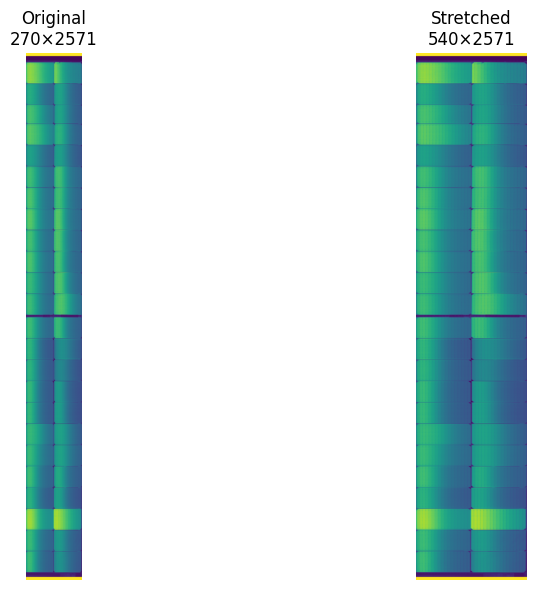

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

# ── Input / Output paths ───────────────────────────────────────────
INPUT_PATH  = "extracted_content.png"
OUTPUT_PATH = "stretched_output.png"

# ── Stretch factors ────────────────────────────────────────────────
SCALE_X = 2   # horizontal stretch
SCALE_Y = 1   # vertical stretch

# ── Load image ─────────────────────────────────────────────────────
img = Image.open(INPUT_PATH)

# ── Resize ─────────────────────────────────────────────────────────
new_width  = img.width * SCALE_X
new_height = img.height * SCALE_Y

stretched = img.resize((new_width, new_height), Image.LANCZOS)
stretched.save(OUTPUT_PATH)

# ── Print info ─────────────────────────────────────────────────────
print(f"Original  : {img.width} x {img.height}")
print(f"Stretched : {new_width} x {new_height}")
print(f"Saved to  : {OUTPUT_PATH}")

# ── Display below cell ─────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img)
ax[0].set_title(f"Original\n{img.width}×{img.height}")
ax[0].axis("off")

ax[1].imshow(stretched)
ax[1].set_title(f"Stretched\n{new_width}×{new_height}")
ax[1].axis("off")

plt.tight_layout()
plt.show()